In [808]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import warnings
warnings.filterwarnings("ignore")
import pandas_datareader as pdr
import datetime 
from sklearn.linear_model import Ridge , LinearRegression, Lasso , ElasticNet
from sklearn.metrics import mean_absolute_error

In [809]:
class Data_preprocessing:
    def __init__(self , symvol , train_start , train_finish , valid_start , valid_finish , test_start, test_finish):
        self.data = pdr.get_data_yahoo(symvol, 
                          start=datetime.datetime([int(i) for i in train_start.split('-')][0], [int(i) for i in train_start.split('-')][1], [int(i) for i in train_start.split('-')][2]), 
                          end=datetime.datetime([int(i) for i in test_finish.split('-')][0], [int(i) for i in test_finish.split('-')][1], [int(i) for i in test_finish.split('-')][2]))
        self.train_start = train_start
        self.train_finish = train_finish
        self.valid_start = valid_start
        self.valid_finish = valid_finish
        self.test_start = test_start
        self.test_finish = test_finish
        
        
    def get_train_data(self):
        self.data['Date'] = self.data.index
        self.data['year'] = self.data['Date'].dt.year
        self.data['month'] = self.data['Date'].dt.month
        self.data['day'] = self.data['Date'].dt.day
        return self.data[self.data.index <= self.train_finish]
    
    def get_valid_data(self):
        self.data['Date'] = self.data.index
        self.data['year'] = self.data['Date'].dt.year
        self.data['month'] = self.data['Date'].dt.month
        self.data['day'] = self.data['Date'].dt.day
        return self.data[(self.data.index > self.valid_start) & (self.data.index <= self.valid_finish)]
    
    def get_test_data(self):
        self.data['Date'] = self.data.index
        self.data['year'] = self.data['Date'].dt.year
        self.data['month'] = self.data['Date'].dt.month
        self.data['day'] = self.data['Date'].dt.day
        return self.data[(self.data.index > self.test_start) & (self.data.index <= self.test_finish)] 
    
    def ggplot(self , df , short , long):
        plt.figure(figsize=(16,9))
        plt.plot(df['Adj Close'].rolling(short).mean() , label = 'sma short')
        plt.plot(df['Adj Close'].rolling(long).mean() , label = 'sma long')
        plt.plot(df['Adj Close'] , label = 'Adj Close')

In [810]:
# акции - AAPL , IBM , TSLA , MU , ZOM , CRM , SNOW , ZM , WDC , YY и т.д (посмотреть все можно тут https://finance.yahoo.com/trending-tickers) 
prep = Data_preprocessing('AAPL' , '2010-01-01' , '2019-01-31' , '2019-01-31' , '2020-01-31' , '2020-01-31' , '2021-08-13')
train = prep.get_train_data()
valid = prep.get_valid_data()
test = prep.get_test_data()

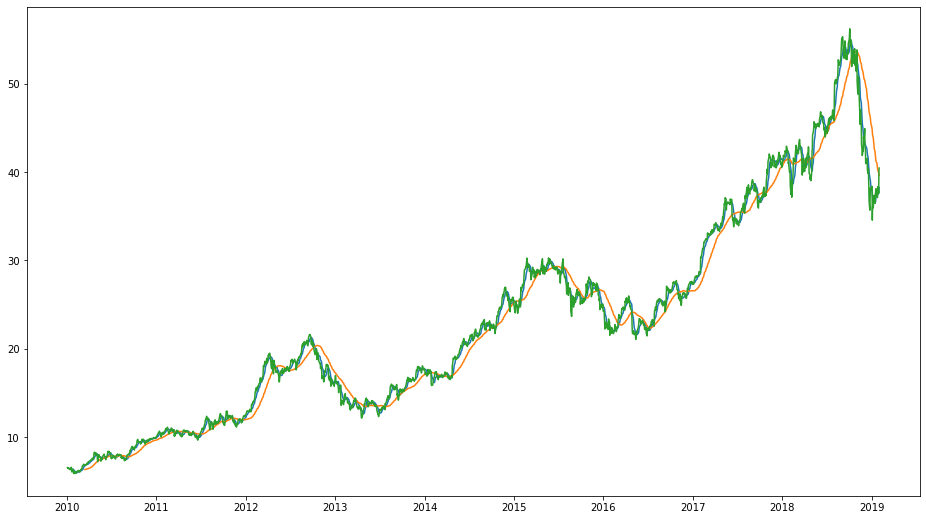

In [811]:
prep.ggplot(train , 10 , 50)

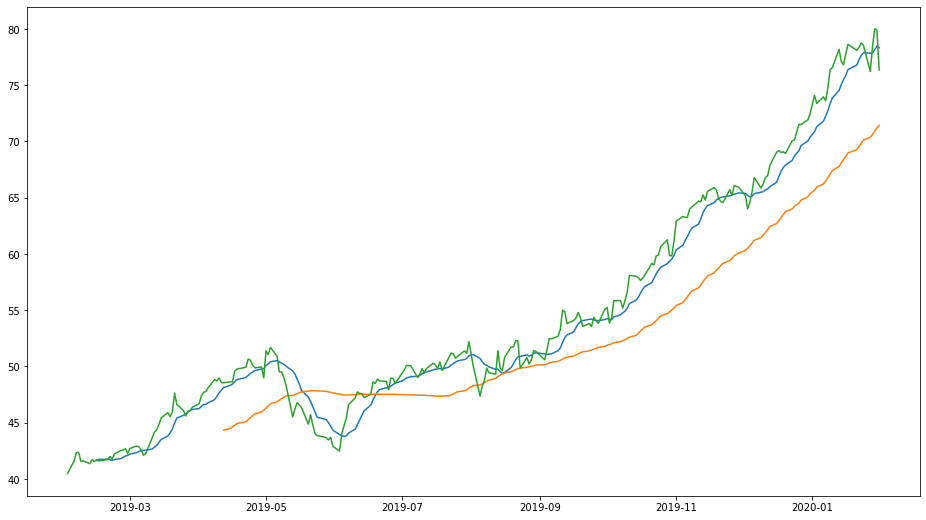

In [812]:
prep.ggplot(valid , 10 , 50)

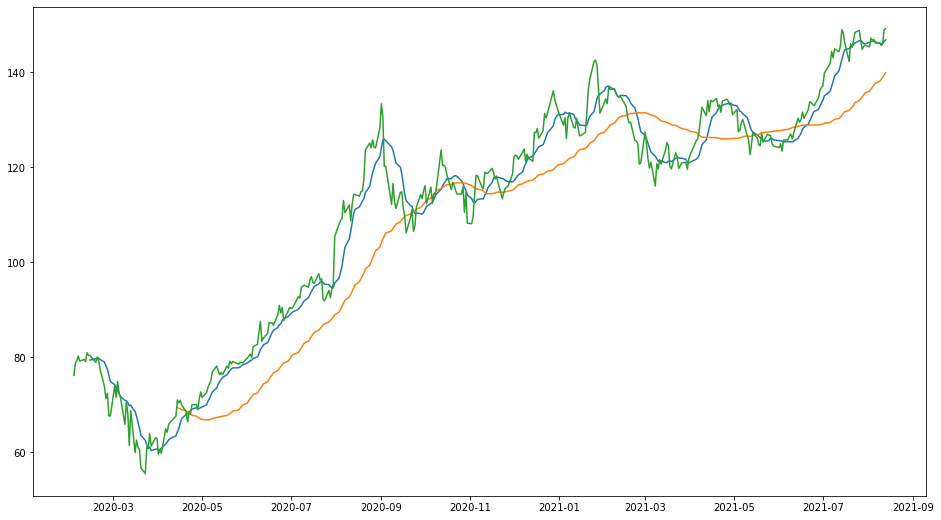

In [813]:
prep.ggplot(test , 10 , 50)

In [814]:
class Strategy(object):
    #выбираем свою модель 
    def __init__(self, you_model):
        self.you_model = you_model
        
    # функция для обучения модели
    def run(self , data):
        #self.model = ElasticNet(alpha = 0.27)
        self.model = self.you_model
        self.model.fit(data.drop(['Close' ,'Adj Close' , 'Date'] , axis = 1), data['Close'])
        print('модель обучилась')
        return self
    
    #функция , чтобы получить датафрэйм с реальными close и прогнозируемыми
    def get_pred(self ,data):
        df = pd.DataFrame()
        df['true'] = data['Close']
        df['pred'] = self.model.predict(data.drop(['Close' , 'Adj Close' , 'Date'] , axis = 1))
        return df
    
    #функция для получения показателя Шарпа
    def bt_sharpe_score(self,data):
        a = pd.Series(self.trade(data)[0])
        print('показатель Шарпа')
        return np.sqrt(252) * a.pct_change().mean() / a.pct_change().std()
    
    #функция для получения отношение накопленной доходности к максимальной просадке
    def bt_drawdown(self , data):
        #R = R1 * 100 / (D + 100)
        #R1 - min , D - max
        print('отношение накопленной доходности к максимальной просадке')
        s = self.get_pred(data)
        return s['pred'].min() * 100 / (s['pred'].max() + 100)
    
    
    def trade(self,data):
        buy = []
        self.flag = []
        for i in range(len(self.get_pred(data))):
            if data['Open'][i] < self.get_pred(data)['pred'][i]:
                buy.append(self.get_pred(data)['pred'][i] - data['Open'][i])
                self.flag.append(self.get_pred(data)['true'][i])
            else:
                buy.append(np.nan)
                self.flag.append(np.nan)
        return [buy , self.flag]
    
    #функция для отображения графика с реальными close и прогнозируемыми , а также отметками дней , когда происходила покупка и продажа
    def ggplot(self , data):
        plt.figure(figsize=(16,9))
        plt.plot(self.get_pred(data)['pred'] , label = 'pred')
        plt.plot(self.get_pred(data)['true'], label = 'true')
        plt.scatter(data.index, self.trade(data)[1] , marker = '*' , linewidths = 1 , label = '')
        plt.legend(loc = 'upper left')

In [815]:
s = Strategy(Ridge())
s.run(train)
print(s.bt_sharpe_score(valid))
print(s.bt_drawdown(valid))

модель обучилась
показатель Шарпа
3.3381669504598204
отношение накопленной доходности к максимальной просадке
23.155211071175163


In [816]:
s = Strategy(Lasso())
s.run(train)
print(s.bt_sharpe_score(valid))
print(s.bt_drawdown(valid))

модель обучилась
показатель Шарпа
2.2895722303811663
отношение накопленной доходности к максимальной просадке
23.135688242743676


In [817]:
s = Strategy(ElasticNet())
s.run(train)
print(s.bt_sharpe_score(valid))
print(s.bt_drawdown(valid))

модель обучилась
показатель Шарпа
1.3133136579240126
отношение накопленной доходности к максимальной просадке
23.102702852799823


In [818]:
s = Strategy(LinearRegression())
s.run(train)
print(s.bt_sharpe_score(valid))
print(s.bt_drawdown(valid))

модель обучилась
показатель Шарпа
3.3508954424441995
отношение накопленной доходности к максимальной просадке
23.156012881594247


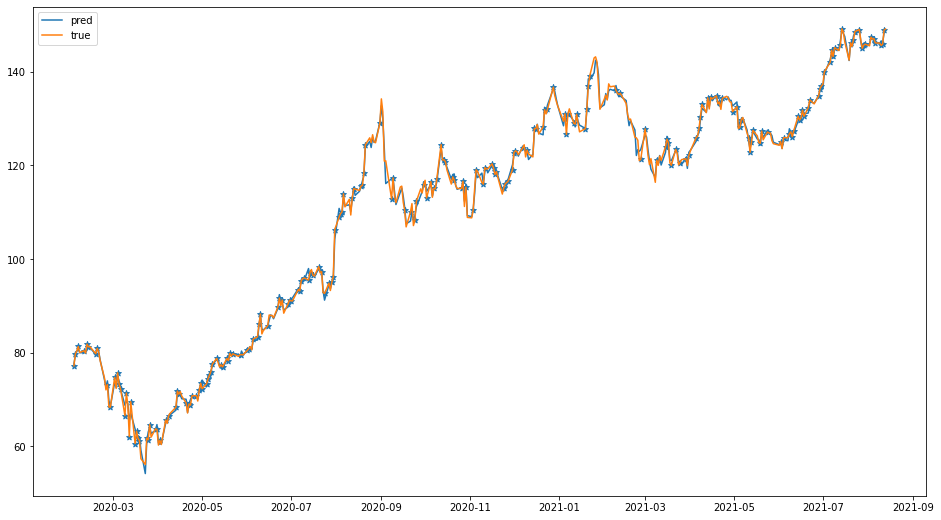

In [819]:
s.ggplot(test)

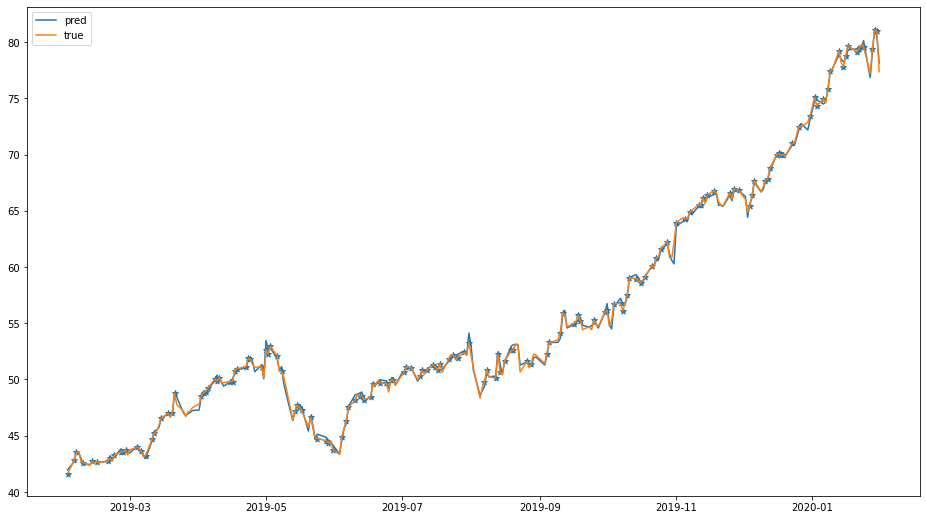

In [820]:
s.ggplot(valid)